Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras

print(tf.__version__)

plt.style.use("default")
%matplotlib inline

I0000 00:00:1775820481.660618    1384 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775820482.391360    1384 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775820484.263967    1384 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0


Dataset: 

In [2]:
data_dir_rgb = "../data/EuroSAT_RGB"
data_dir_ms = "../data/EuroSAT_MS"

classes = sorted(os.listdir(data_dir_rgb))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [3]:
class_counts = {cls: len(os.listdir(os.path.join(data_dir_rgb, cls))) for cls in classes}
class_counts

{'AnnualCrop': 3000,
 'Forest': 3000,
 'HerbaceousVegetation': 3000,
 'Highway': 2500,
 'Industrial': 2500,
 'Pasture': 2000,
 'PermanentCrop': 2500,
 'Residential': 3000,
 'River': 2500,
 'SeaLake': 3000}

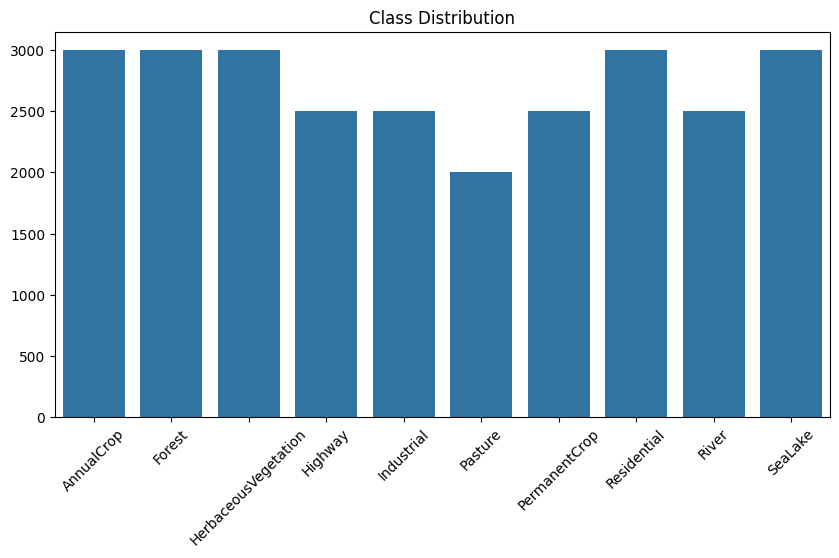

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Er det balansert?

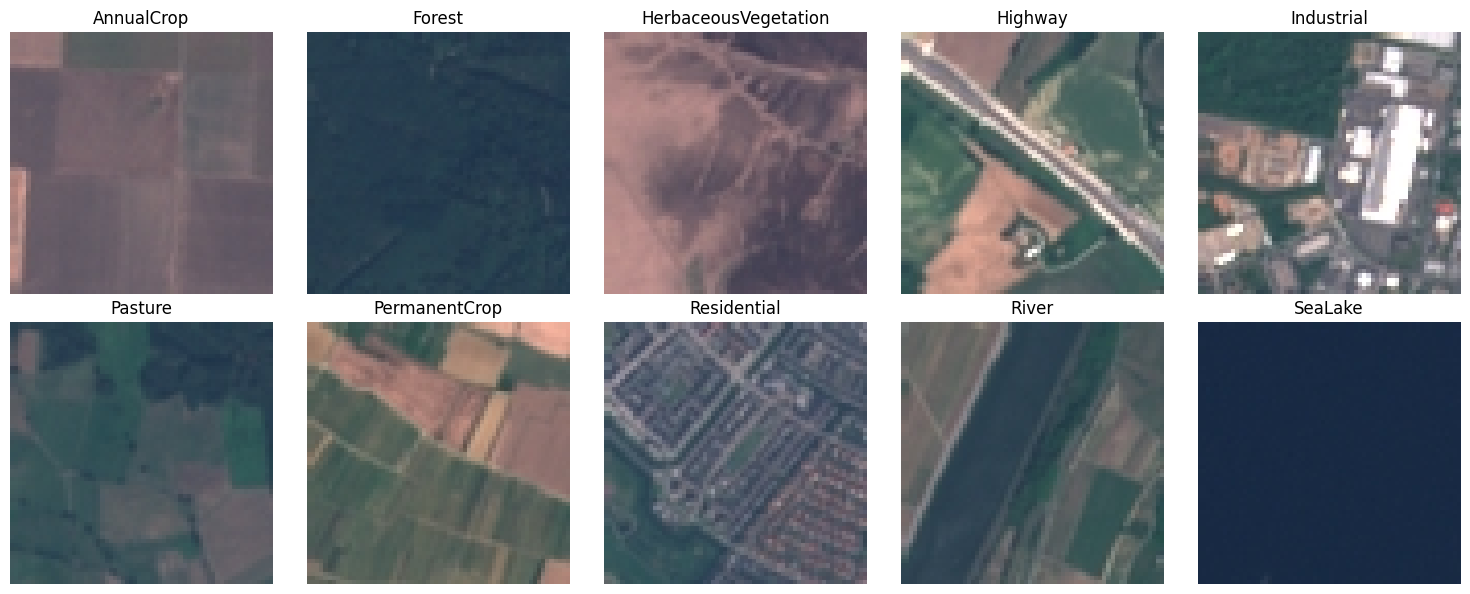

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, cls in enumerate(classes[:10]):
    img_path = os.path.join(data_dir_rgb, cls, os.listdir(os.path.join(data_dir_rgb, cls))[0])
    img = Image.open(img_path)
    
    ax = axes[i//5, i%5]
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
sample_class = classes[0]
sample_path = os.path.join(data_dir_ms, sample_class, os.listdir(os.path.join(data_dir_ms, sample_class))[0])

with rasterio.open(sample_path) as src:
    img = src.read()

print("Shape:", img.shape)  # (13, H, W)

Shape: (13, 64, 64)


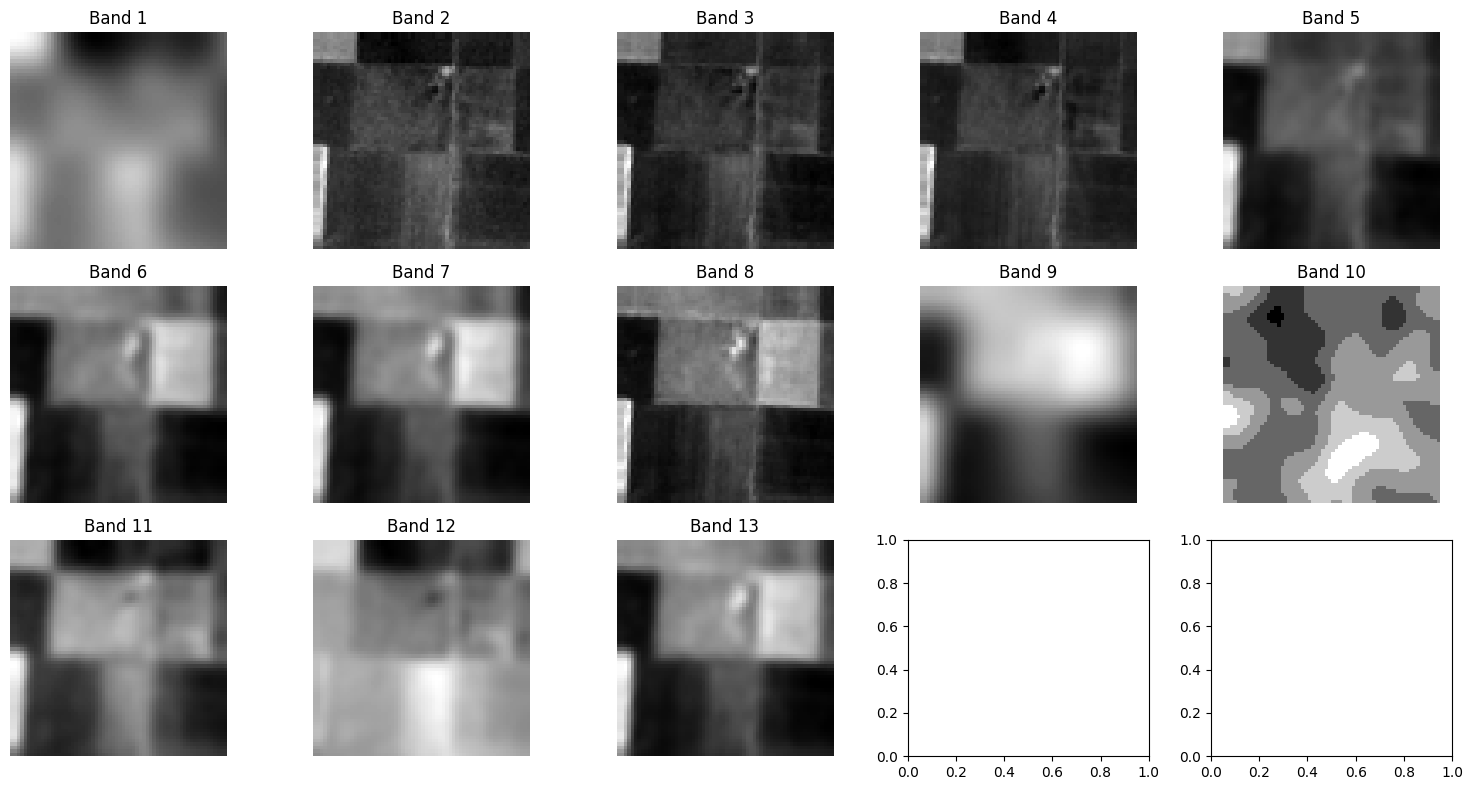

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(15,8))

for i in range(img.shape[0]):
    ax = axes[i//5, i%5]
    ax.imshow(img[i], cmap='gray')
    ax.set_title(f'Band {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

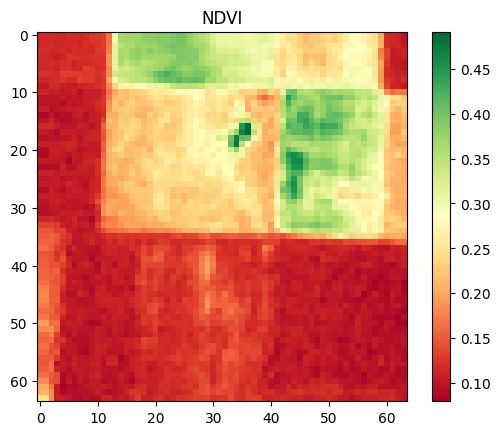

In [8]:
nir = img[7]
red = img[3]

ndvi = (nir - red) / (nir + red + 1e-6)

plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar()
plt.title("NDVI")
plt.show()

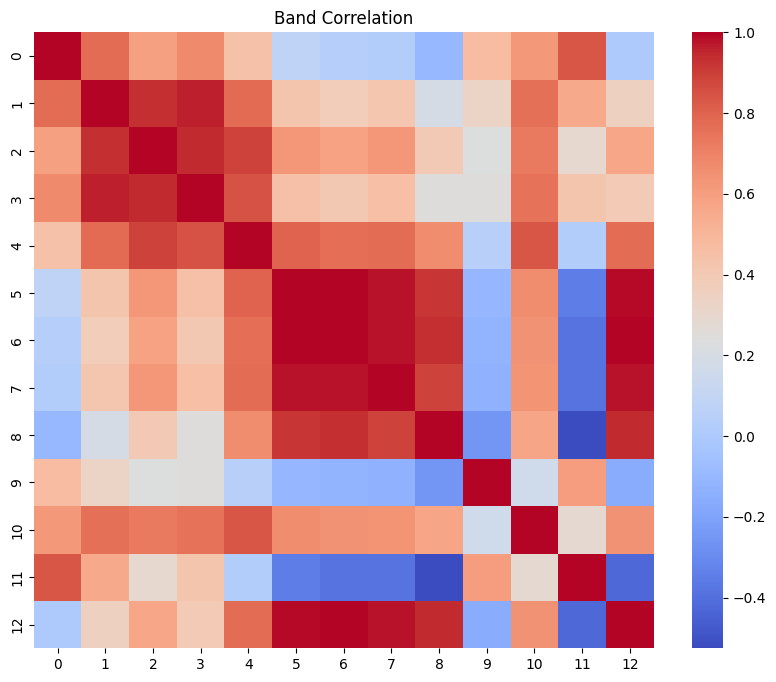

In [9]:
flattened = img.reshape(img.shape[0], -1)
corr = np.corrcoef(flattened)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Band Correlation")
plt.show()